
# Preparing the script




Package Talos Installation

In [ ]:
!pip install git+https://github.com/autonomio/talos

  Cloning https://github.com/autonomio/talos to /tmp/pip-req-build-wzn01few
  Running command git clone -q https://github.com/autonomio/talos /tmp/pip-req-build-wzn01few
  Using cached https://files.pythonhosted.org/packages/de/f0/96fb2e0412ae9692dbf400e5b04432885f677ad6241c088ccc5fe7724d69/tensorflow-1.14.0-cp36-cp36m-manylinux1_x86_64.whl
Processing /root/.cache/pip/wheels/ae/70/21/c475cd079ec401dd6e1b9b1d42b4c38554ce12679bfb214aad/astetik-1.9.9-cp36-none-any.whl
Processing /root/.cache/pip/wheels/75/33/46/c871b94249bd57d17797d049b3dff8e3a09c315afb67eb14c6/chances-0.1.9-cp36-none-any.whl
Processing /root/.cache/pip/wheels/9d/d3/8c/9503a22b0a38e8b21c70ad834e4606d209193443e5c709305d/kerasplotlib-0.1.6-cp36-none-any.whl
  Using cached https://files.pythonhosted.org/packages/32/c1/efb823270c8526b2f4f3eb8c804c5a0a55277267ad2312f5eb47bd9cc370/geonamescache-1.1.0-py3-none-any.whl
  Created wheel for talos: filename=talos-0.6.7-cp36-none-any.whl size=53512 sha256=416b36b0820ab098223c81f35062

Libraries import

In [ ]:
import keras
import os
import tensorflow as tf

# Packages
import pandas as pd
import numpy as np

from keras import layers
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Input
from keras.datasets import fashion_mnist
from keras.utils import np_utils
from keras.layers.core import Dropout
from keras import losses, optimizers

import matplotlib.pyplot as pyplot

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from math import sqrt
from math import pow


import sys
sys.path.insert(0, './talos/')

import sys
sys.path.insert(0, './wrangle/')

import talos
import wrangle
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from talos import model

from keras.optimizers import Adam, Nadam

from numpy import random
from random import seed
from numpy import multiply

from matplotlib.pyplot import plot

Function defining for denormalizing data and normalizing

In [ ]:
def denorm0(normalized):
  max = 1882.325 #max from R data preprocessing
  min = 1.291071 #min from R data preprocessing
  return ((normalized)*(max-min))+min

def denorm0Prec(normalized):
  max = 186 #max from R data preprocessing
  min = 0 #min from R data preprocessing
  return ((normalized)*(max-min))+min

def normalize(denormalized):
  return (denormalized - min(denormalized))/(max(denormalized) -  min(denormalized))

def nse(y_true, y_pred):
  return 1 - (np.sum((np.add(y_true,-y_pred))**2)/np.sum((y_true-np.mean(y_true))**2))

Load data preprocessed in R in previous project

In [ ]:
# Importazione datasets
dsMISO1 = pd.read_csv('https://raw.githubusercontent.com/michelepini/progettoDL/master/dataset_complete.csv')
dsMISO2 = pd.read_csv('https://raw.githubusercontent.com/michelepini/progettoDL/master/dataset_complete2.csv')
dsMISO3 = pd.read_csv('https://raw.githubusercontent.com/michelepini/progettoDL/master/dataset_complete3.csv')

Visualize MISO1 Dataset

In [ ]:
dsMISO1.head()

,Date,IN_p1d,SEAS_p1d,IN,SEAS,WL_MM_1d,IN_1d,OUT_1d,WL_MM_2d,IN_2d,OUT_2d,MEAN_7d,SD_7d,Prec_S,Tmax_S,Tmin_S,Snow_S
0,1946-01-01,0.050082,1,0.033543,1,0.616828,0.029694,0.118535,0.626420,0.030701,0.117526,0.031107,0.009839,0.0,6.2,-7.0,0
1,1946-01-02,0.034687,1,0.050082,1,0.554559,0.033543,0.119544,0.616828,0.029694,0.118535,0.033876,0.010686,0.0,6.0,-8.6,0
2,1946-01-03,0.016560,1,0.034687,1,0.545590,0.050082,0.098508,0.554559,0.033543,0.119544,0.034589,0.011102,0.0,2.6,-10.0,0
3,1946-01-04,0.043609,1,0.016560,1,0.545590,0.034687,0.085191,0.545590,0.050082,0.098508,0.032425,0.011562,0.0,3.2,-9.0,0
4,1946-01-05,0.043609,1,0.043609,1,0.542601,0.016560,0.084610,0.545590,0.034687,0.085191,0.034125,0.011539,0.0,4.4,-10.2,0


Visualize MISO2 Dataset

In [ ]:
dsMISO2.head()

,Date,IN_p2d,SEAS_p2d,IN_p1d,IN,SEAS,WL_MM_1d,IN_1d,OUT_1d,MEAN_7d,SD_7d,Prec_S,Tmax_S,Tmin_S,Snow_S
0,1946-01-01,0.034687,1,0.050082,0.033543,1,0.616828,0.029694,0.118535,0.031107,0.009839,0.0,6.2,-7.0,0
1,1946-01-02,0.016560,1,0.034687,0.050082,1,0.554559,0.033543,0.119544,0.033876,0.010686,0.0,6.0,-8.6,0
2,1946-01-03,0.043609,1,0.016560,0.034687,1,0.545590,0.050082,0.098508,0.034589,0.011102,0.0,2.6,-10.0,0
3,1946-01-04,0.043609,1,0.043609,0.016560,1,0.545590,0.034687,0.085191,0.032425,0.011562,0.0,3.2,-9.0,0
4,1946-01-05,0.025765,1,0.043609,0.043609,1,0.542601,0.016560,0.084610,0.034125,0.011539,0.0,4.4,-10.2,0


Visualize MISO3 Dataset

In [ ]:
dsMISO3.head()

,Date,IN_p3d,SEAS_p3d,IN_p2d,IN_p1d,IN,SEAS,MEAN_7d,SD_7d,Prec_S,Tmax_S,Tmin_S,Snow_S
0,1946-01-01,0.016560,1,0.034687,0.050082,0.033543,1,0.031107,0.009839,0.0,6.2,-7.0,0
1,1946-01-02,0.043609,1,0.016560,0.034687,0.050082,1,0.033876,0.010686,0.0,6.0,-8.6,0
2,1946-01-03,0.043609,1,0.043609,0.016560,0.034687,1,0.034589,0.011102,0.0,2.6,-10.0,0
3,1946-01-04,0.025765,1,0.043609,0.043609,0.016560,1,0.032425,0.011562,0.0,3.2,-9.0,0
4,1946-01-05,0.034687,1,0.025765,0.043609,0.043609,1,0.034125,0.011539,0.0,4.4,-10.2,0


# Forecasts

Generating forecasts and past values for precipitations.

In MISO1, there will be 3 days of actual values and 1 forecast.

In MISO2, there will be 2 days of actual values and 2 forecasts.

In MISO3, there will be 1 day of actual value and 3 forecasts.

Adding of 3 columns initially empty (0 value), where there will be the values after replacing.

In [ ]:
dsMISO1.insert(13, "Prec_S_2d", 0.0)
dsMISO1.insert(14, "Prec_S_1d", 0.0)
dsMISO1.insert(16, "Prec_S_f1d", 0.0)
dsMISO1.head()

,Date,IN_p1d,SEAS_p1d,IN,SEAS,WL_MM_1d,IN_1d,OUT_1d,WL_MM_2d,IN_2d,OUT_2d,MEAN_7d,SD_7d,Prec_S_2d,Prec_S_1d,Prec_S,Prec_S_f1d,Tmax_S,Tmin_S,Snow_S
0,1946-01-01,0.050082,1,0.033543,1,0.616828,0.029694,0.118535,0.626420,0.030701,0.117526,0.031107,0.009839,0.0,0.0,0.0,0.0,6.2,-7.0,0
1,1946-01-02,0.034687,1,0.050082,1,0.554559,0.033543,0.119544,0.616828,0.029694,0.118535,0.033876,0.010686,0.0,0.0,0.0,0.0,6.0,-8.6,0
2,1946-01-03,0.016560,1,0.034687,1,0.545590,0.050082,0.098508,0.554559,0.033543,0.119544,0.034589,0.011102,0.0,0.0,0.0,0.0,2.6,-10.0,0
3,1946-01-04,0.043609,1,0.016560,1,0.545590,0.034687,0.085191,0.545590,0.050082,0.098508,0.032425,0.011562,0.0,0.0,0.0,0.0,3.2,-9.0,0
4,1946-01-05,0.043609,1,0.043609,1,0.542601,0.016560,0.084610,0.545590,0.034687,0.085191,0.034125,0.011539,0.0,0.0,0.0,0.0,4.4,-10.2,0


The same for MISO2.

In [ ]:
dsMISO2.insert(11, "Prec_S_1d", 0.0)
dsMISO2.insert(13, "Prec_S_f1d", 0.0)
dsMISO2.insert(14, "Prec_S_f2d", 0.0)
dsMISO2.head()

,Date,IN_p2d,SEAS_p2d,IN_p1d,IN,SEAS,WL_MM_1d,IN_1d,OUT_1d,MEAN_7d,SD_7d,Prec_S_1d,Prec_S,Prec_S_f1d,Prec_S_f2d,Tmax_S,Tmin_S,Snow_S
0,1946-01-01,0.034687,1,0.050082,0.033543,1,0.616828,0.029694,0.118535,0.031107,0.009839,0.0,0.0,0.0,0.0,6.2,-7.0,0
1,1946-01-02,0.016560,1,0.034687,0.050082,1,0.554559,0.033543,0.119544,0.033876,0.010686,0.0,0.0,0.0,0.0,6.0,-8.6,0
2,1946-01-03,0.043609,1,0.016560,0.034687,1,0.545590,0.050082,0.098508,0.034589,0.011102,0.0,0.0,0.0,0.0,2.6,-10.0,0
3,1946-01-04,0.043609,1,0.043609,0.016560,1,0.545590,0.034687,0.085191,0.032425,0.011562,0.0,0.0,0.0,0.0,3.2,-9.0,0
4,1946-01-05,0.025765,1,0.043609,0.043609,1,0.542601,0.016560,0.084610,0.034125,0.011539,0.0,0.0,0.0,0.0,4.4,-10.2,0


Again for MISO3

In [ ]:
dsMISO3.insert(10, "Prec_S_f1d", 0.0)
dsMISO3.insert(11, "Prec_S_f2d", 0.0)
dsMISO3.insert(12, "Prec_S_f3d", 0.0)
dsMISO3.head()

,Date,IN_p3d,SEAS_p3d,IN_p2d,IN_p1d,IN,SEAS,MEAN_7d,SD_7d,Prec_S,Prec_S_f1d,Prec_S_f2d,Prec_S_f3d,Tmax_S,Tmin_S,Snow_S
0,1946-01-01,0.016560,1,0.034687,0.050082,0.033543,1,0.031107,0.009839,0.0,0.0,0.0,0.0,6.2,-7.0,0
1,1946-01-02,0.043609,1,0.016560,0.034687,0.050082,1,0.033876,0.010686,0.0,0.0,0.0,0.0,6.0,-8.6,0
2,1946-01-03,0.043609,1,0.043609,0.016560,0.034687,1,0.034589,0.011102,0.0,0.0,0.0,0.0,2.6,-10.0,0
3,1946-01-04,0.025765,1,0.043609,0.043609,0.016560,1,0.032425,0.011562,0.0,0.0,0.0,0.0,3.2,-9.0,0
4,1946-01-05,0.034687,1,0.025765,0.043609,0.043609,1,0.034125,0.011539,0.0,0.0,0.0,0.0,4.4,-10.2,0


# Noise

Adding Noise to columns of forecast, calculated with Gaussian Distribution with:
- as **mean** the actual value of precipitation
- as **variance** a value given by product between mean and a costant that works as an hyperparameter

In [ ]:
percNoise_1d = 0.2
percNoise_2d = 0.4
percNoise_3d = 0.6
seed(20191216)

Function to add noise to data

In [ ]:
def noising(value, perc):
  return random.normal(value, value*perc)

Denormalization of data, to come back from [0,1] to real values of precipitations in millimeters.

In [ ]:
dsMISO1.Prec_S = denorm0Prec(dsMISO1.Prec_S)
dsMISO2.Prec_S = denorm0Prec(dsMISO2.Prec_S)
dsMISO3.Prec_S = denorm0Prec(dsMISO3.Prec_S)

# Forecast and past values derivation

Derivation of values in different time moments for MISO1:
- Prec_2d as the actual value of 2 days before
- Prec_1d as the actual value of 1 day before
- Prec_f1d as the randomized value that approximated 1-day-forecast

In [ ]:
for i in range(2,len(dsMISO1)-1):
  dsMISO1.Prec_S_2d[i] = dsMISO1.Prec_S[i-2]
  dsMISO1.Prec_S_1d[i] = dsMISO1.Prec_S[i-1]
  dsMISO1.Prec_S_f1d[i] = noising(dsMISO1.Prec_S[i+1], percNoise_1d)
dsMISO1[dsMISO1.Date > '1946-01-19'].head()

Derivation of values in different time moments for MISO2:
- Prec_1d as the actual value of 1 day before
- Prec_f1d as the randomized value that approximated 1-day-forecast
- Prec_f2d as the randomized value that approximated 2-day-forecast

In [ ]:
for i in range(1,len(dsMISO2)-2):
  dsMISO2.Prec_S_1d[i] = dsMISO2.Prec_S[i-1]
  dsMISO2.Prec_S_f1d[i] = noising(dsMISO2.Prec_S[i+1], percNoise_1d)
  dsMISO2.Prec_S_f2d[i] = noising(dsMISO2.Prec_S[i+2], percNoise_2d)
dsMISO2[dsMISO2.Date > '1946-01-19'].head()

Derivation of values in different time moments for MISO2:
- Prec_f1d as the randomized value that approximated 1-day-forecast
- Prec_f2d as the randomized value that approximated 2-day-forecast
- Prec_f3d as the randomized value that approximated 3-day-forecast

In [ ]:
for i in range(0,len(dsMISO3)-3):
  dsMISO3.Prec_S_f1d[i] = noising(dsMISO3.Prec_S[i+1], percNoise_1d)
  dsMISO3.Prec_S_f2d[i] = noising(dsMISO3.Prec_S[i+2], percNoise_2d)
  dsMISO3.Prec_S_f3d[i] = noising(dsMISO3.Prec_S[i+3], percNoise_3d)
dsMISO3[dsMISO3.Date > '1946-01-19'].head()

Re-normalizing of all columns to re-obtain values between 0 and 1

In [ ]:
dsMISO1.Prec_S_2d = normalize(dsMISO1.Prec_S_2d)
dsMISO1.Prec_S_1d = normalize(dsMISO1.Prec_S_1d)
dsMISO1.Prec_S = normalize(dsMISO1.Prec_S)
dsMISO1.Prec_S_f1d = normalize(dsMISO1.Prec_S_f1d)

dsMISO2.Prec_S_1d = normalize(dsMISO2.Prec_S_1d)
dsMISO2.Prec_S = normalize(dsMISO2.Prec_S)
dsMISO2.Prec_S_f1d = normalize(dsMISO2.Prec_S_f1d)
dsMISO2.Prec_S_f2d = normalize(dsMISO2.Prec_S_f2d)

dsMISO3.Prec_S = normalize(dsMISO3.Prec_S)
dsMISO3.Prec_S_f1d = normalize(dsMISO3.Prec_S_f1d)
dsMISO3.Prec_S_f2d = normalize(dsMISO3.Prec_S_f2d)
dsMISO3.Prec_S_f3d = normalize(dsMISO3.Prec_S_f3d)

# Feature selection

Drop of columns in order to mantain only the best feautes according to feature selection work done in the past project.

In [ ]:
dsMISO1 = dsMISO1.drop(columns=['SEAS_p1d','SEAS','Tmax_S','Tmin_S'])
dsMISO1

,Date,IN_p1d,IN,WL_MM_1d,IN_1d,OUT_1d,WL_MM_2d,IN_2d,OUT_2d,MEAN_7d,SD_7d,Prec_S_2d,Prec_S_1d,Prec_S,Prec_S_f1d,Snow_S
0,1946-01-01,0.050082,0.033543,0.616828,0.029694,0.118535,0.626420,0.030701,0.117526,0.031107,0.009839,0.0,0.0,0.0,0.0,0
1,1946-01-02,0.034687,0.050082,0.554559,0.033543,0.119544,0.616828,0.029694,0.118535,0.033876,0.010686,0.0,0.0,0.0,0.0,0
2,1946-01-03,0.016560,0.034687,0.545590,0.050082,0.098508,0.554559,0.033543,0.119544,0.034589,0.011102,0.0,0.0,0.0,0.0,0
3,1946-01-04,0.043609,0.016560,0.545590,0.034687,0.085191,0.545590,0.050082,0.098508,0.032425,0.011562,0.0,0.0,0.0,0.0,0
4,1946-01-05,0.043609,0.043609,0.542601,0.016560,0.084610,0.545590,0.034687,0.085191,0.034125,0.011539,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21832,2016-12-23,0.037909,0.042863,0.324365,0.051401,0.128751,0.328849,0.051918,0.129813,0.051816,0.011341,0.0,0.0,0.0,0.0,0
21833,2016-12-24,0.028571,0.037909,0.319880,0.042863,0.129540,0.324365,0.051401,0.128751,0.049177,0.014757,0.0,0.0,0.0,0.0,0
21834,2016-12-25,0.056451,0.028571,0.312407,0.037909,0.128526,0.319880,0.042863,0.129540,0.048512,0.014400,0.0,0.0,0.0,0.0,0
21835,2016-12-26,0.015035,0.056451,0.303438,0.028571,0.127671,0.312407,0.037909,0.128526,0.047177,0.013283,0.0,0.0,0.0,0.0,0


In [ ]:
dsMISO2 = dsMISO2.drop(columns=['SEAS','SEAS_p2d','Tmax_S','Tmin_S'])
dsMISO2.head()

,Date,IN_p2d,IN_p1d,IN,WL_MM_1d,IN_1d,OUT_1d,MEAN_7d,SD_7d,Prec_S_1d,Prec_S,Prec_S_f1d,Prec_S_f2d,Snow_S
0,1946-01-01,0.034687,0.050082,0.033543,0.616828,0.029694,0.118535,0.031107,0.009839,0.0,0.0,0.0,0.0,0
1,1946-01-02,0.016560,0.034687,0.050082,0.554559,0.033543,0.119544,0.033876,0.010686,0.0,0.0,0.0,0.0,0
2,1946-01-03,0.043609,0.016560,0.034687,0.545590,0.050082,0.098508,0.034589,0.011102,0.0,0.0,0.0,0.0,0
3,1946-01-04,0.043609,0.043609,0.016560,0.545590,0.034687,0.085191,0.032425,0.011562,0.0,0.0,0.0,0.0,0
4,1946-01-05,0.025765,0.043609,0.043609,0.542601,0.016560,0.084610,0.034125,0.011539,0.0,0.0,0.0,0.0,0


In [ ]:
dsMISO3 = dsMISO3.drop(columns=['SEAS','SEAS_p3d','Tmax_S','Tmin_S'])
dsMISO3.head()

,Date,IN_p3d,IN_p2d,IN_p1d,IN,MEAN_7d,SD_7d,Prec_S,Prec_S_f1d,Prec_S_f2d,Prec_S_f3d,Snow_S
0,1946-01-01,0.016560,0.034687,0.050082,0.033543,0.031107,0.009839,0.0,0.0,0.0,0.0,0
1,1946-01-02,0.043609,0.016560,0.034687,0.050082,0.033876,0.010686,0.0,0.0,0.0,0.0,0
2,1946-01-03,0.043609,0.043609,0.016560,0.034687,0.034589,0.011102,0.0,0.0,0.0,0.0,0
3,1946-01-04,0.025765,0.043609,0.043609,0.016560,0.032425,0.011562,0.0,0.0,0.0,0.0,0
4,1946-01-05,0.034687,0.025765,0.043609,0.043609,0.034125,0.011539,0.0,0.0,0.0,0.0,0


# Train-Test splitting
Split fixed at
- 80% training
- 20% testing

In [ ]:
# MISO1
train_index = int(4/5 * len(dsMISO1))
dsMISO1_train, dsMISO1_test = dsMISO1[:train_index], dsMISO1[train_index:]

In [ ]:
# MISO2
train_index = int(4/5 * len(dsMISO2))
dsMISO2_train, dsMISO2_test = dsMISO2[:train_index], dsMISO2[train_index:]
len(dsMISO2_train)

17469

In [ ]:
# MISO3
train_index = int(4/5 * len(dsMISO3))
dsMISO3_train, dsMISO3_test = dsMISO3[:train_index], dsMISO3[train_index:]


In [ ]:
dsMISO1_train

,Date,IN_p1d,IN,WL_MM_1d,IN_1d,OUT_1d,WL_MM_2d,IN_2d,OUT_2d,MEAN_7d,SD_7d,Prec_S_2d,Prec_S_1d,Prec_S,Prec_S_f1d,Snow_S
0,1946-01-01,0.050082,0.033543,0.616828,0.029694,0.118535,0.626420,0.030701,0.117526,0.031107,0.009839,0.0,0.0,0.000000,0.0,0
1,1946-01-02,0.034687,0.050082,0.554559,0.033543,0.119544,0.616828,0.029694,0.118535,0.033876,0.010686,0.0,0.0,0.000000,0.0,0
2,1946-01-03,0.016560,0.034687,0.545590,0.050082,0.098508,0.554559,0.033543,0.119544,0.034589,0.011102,0.0,0.0,0.000000,0.0,0
3,1946-01-04,0.043609,0.016560,0.545590,0.034687,0.085191,0.545590,0.050082,0.098508,0.032425,0.011562,0.0,0.0,0.000000,0.0,0
4,1946-01-05,0.043609,0.043609,0.542601,0.016560,0.084610,0.545590,0.034687,0.085191,0.034125,0.011539,0.0,0.0,0.000000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17464,2003-09-26,0.022307,0.031318,0.107623,0.044859,0.051056,0.110613,0.016767,0.048328,0.029081,0.009765,0.0,0.0,0.000000,0.0,0
17465,2003-09-27,0.031742,0.022307,0.113602,0.031318,0.050730,0.107623,0.044859,0.051056,0.029773,0.009213,0.0,0.0,0.000000,0.0,0
17466,2003-09-28,0.026998,0.031742,0.115097,0.022307,0.050548,0.113602,0.031318,0.050730,0.031740,0.008540,0.0,0.0,0.003226,0.0,1
17467,2003-09-29,0.036362,0.026998,0.113602,0.031742,0.051602,0.115097,0.022307,0.050548,0.030612,0.007266,0.0,0.0,0.001075,0.0,1


In [ ]:
dsMISO1_test

,Date,IN_p1d,IN,WL_MM_1d,IN_1d,OUT_1d,WL_MM_2d,IN_2d,OUT_2d,MEAN_7d,SD_7d,Prec_S_2d,Prec_S_1d,Prec_S,Prec_S_f1d,Snow_S
17469,2003-10-01,0.036503,0.044771,0.115097,0.036362,0.051930,0.115097,0.026998,0.051020,0.034051,0.013395,0.0,0.0,0.001075,0.0,1
17470,2003-10-02,0.054966,0.036503,0.118087,0.044771,0.050875,0.115097,0.036362,0.051930,0.032857,0.012777,0.0,0.0,0.000000,0.0,0
17471,2003-10-03,0.064560,0.054966,0.124066,0.036503,0.052221,0.118087,0.044771,0.050875,0.036236,0.015298,0.0,0.0,0.027419,0.0,1
17472,2003-10-04,0.050169,0.064560,0.127055,0.054966,0.053494,0.124066,0.036503,0.052221,0.042272,0.015199,0.0,0.0,0.093011,0.0,1
17473,2003-10-05,0.017363,0.050169,0.136024,0.064560,0.054876,0.127055,0.054966,0.053494,0.044904,0.017391,0.0,0.0,0.058602,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21832,2016-12-23,0.037909,0.042863,0.324365,0.051401,0.128751,0.328849,0.051918,0.129813,0.051816,0.011341,0.0,0.0,0.000000,0.0,0
21833,2016-12-24,0.028571,0.037909,0.319880,0.042863,0.129540,0.324365,0.051401,0.128751,0.049177,0.014757,0.0,0.0,0.000000,0.0,0
21834,2016-12-25,0.056451,0.028571,0.312407,0.037909,0.128526,0.319880,0.042863,0.129540,0.048512,0.014400,0.0,0.0,0.000000,0.0,0
21835,2016-12-26,0.015035,0.056451,0.303438,0.028571,0.127671,0.312407,0.037909,0.128526,0.047177,0.013283,0.0,0.0,0.000000,0.0,0


In [ ]:
dsMISO1_train.to_csv("dsMISO1_train.csv", index=False)
dsMISO2_train.to_csv("dsMISO2_train.csv", index=False)
dsMISO3_train.to_csv("dsMISO3_train.csv", index=False)
dsMISO1_test.to_csv("dsMISO1_test.csv", index=False)
dsMISO2_test.to_csv("dsMISO2_test.csv", index=False)
dsMISO3_test.to_csv("dsMISO3_test.csv", index=False)

# MISO1: Talos Grid Search

Dataset splitting in subset of training and subset of validation

In [ ]:
#dsMISO1_trainY = dsMISO1_train.IN_p1d
dsMISO1_testY = dsMISO1_test.IN_p1d
#dsMISO1_trainX = dsMISO1_train.drop(columns='IN_p1d').values
dsMISO1_testX = dsMISO1_test.drop(columns='IN_p1d').values
dsMISO1_trainX, dsMISO1_trainY, dsMISO1_valX, dsMISO1_valY = wrangle.array_split(dsMISO1_train.drop(columns='IN_p1d').values, dsMISO1_train.IN_p1d, .3)


Grid search parameters and MISO1 model definition



In [ ]:
# set the parameter space boundary
p = {
     'lr': [pow(10, -3)],
     'activation':['relu'],
     'optimizer': [optimizers.adam, optimizers.nadam],
     'losses': ['mean_squared_error'],
     'shapes': ['triangle'],
     'first_neuron': [64, 128],
     'hidden_layers':[1],
     'dropout': [.2],
     'batch_size': [128,256,512],
     'epochs': [100, 150, 200],
     'regularizer': [1, 0.6, 0.8]
     #'last_activation': [sigmoid]
     }

# define the input model
def MISO1_model(x_train, y_train, x_val, y_val, params):
    print("\nParams:",params)
    model = Sequential()
    model.add(Dense(params['first_neuron'], input_dim=14, activation=params['activation']))

    talos.utils.hidden_layers(model, params, 1)

    model.add(Dense(1, activation='relu'))
    opt = params['optimizer'](params['lr'], beta_1=0.9, beta_2=0.999)
    model.compile(optimizer=opt, loss=params['losses'], metrics=['mae','mse'])
    #(lr=talos.model.normalizers.lr_normalizer(params['lr']))

    # simple early stopping
    es = EarlyStopping(monitor='val_mae', mode='min', verbose=1, patience=5)

    out = model.fit(x_train, y_train, callbacks=[es],
                    batch_size=params['batch_size'],
                    epochs=params['epochs'],
                    validation_data=[x_val, y_val],
                    #validation_split=0.3,
                    verbose=0)

    return out, model

Avvio della scansione Talos

In [ ]:
# start the experiment
scan_object = talos.Scan(x=dsMISO1_trainX,
                         y=dsMISO1_trainY,
                         x_val=dsMISO1_valX,
                         y_val=dsMISO1_valY,
                         params=p,
                         model=MISO1_model,
                         #grid_downsapmple=0.2,
                         experiment_name='MISO1',
                         round_limit=5
                         )

  0%|          | 0/5 [00:00<?, ?it/s]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 128, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 20%|██        | 1/5 [00:19<01:19, 19.85s/it]


Params: {'activation': 'relu', 'batch_size': 128, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 40%|████      | 2/5 [00:51<01:09, 23.29s/it]

...

 60%|██████    | 3/5 [01:10<00:43, 21.97s/it]


Params: {'activation': 'relu', 'batch_size': 128, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 128, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 80%|████████  | 4/5 [01:28<00:20, 20.97s/it]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


100%|██████████| 5/5 [01:41<00:00, 18.49s/it]


Scan reporting with visualization of results

In [ ]:
# Make a report on the scan
r = talos.Reporting(scan_object)
# Show the models
display(r.data)

,round_epochs,val_loss,val_mean_absolute_error,val_mean_squared_error,loss,mean_absolute_error,mean_squared_error,activation,batch_size,dropout,epochs,first_neuron,hidden_layers,losses,lr,optimizer,regularizer,shapes
0,200,0.000938,0.017631,0.000938,0.000625,0.016006,0.000625,relu,512,0.2,200,128,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.6,triangle
1,200,0.000918,0.016707,0.000918,0.000676,0.016613,0.000676,relu,128,0.2,200,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.8,triangle
2,150,0.000942,0.016806,0.000942,0.000613,0.015941,0.000613,relu,256,0.2,150,128,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.6,triangle
3,100,0.000917,0.016859,0.000917,0.000646,0.016157,0.000646,relu,128,0.2,100,128,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.8,triangle
4,200,0.000902,0.017085,0.000902,0.000771,0.017404,0.000771,relu,512,0.2,200,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.6,triangle


In [ ]:
r['val_mean_squared_error'].idxmin()

TypeError: ignored

In [ ]:
r.high

In [ ]:
rdf = pd.DataFrame(data=r)

ValueError: ignored

**Best model selection** using as index the mean squared error in validation

In [ ]:
best_configuration = r.data[r.data['val_mean_squared_error'] == r.low('val_mean_squared_error')]
best_configuration

,round_epochs,val_loss,val_mean_absolute_error,val_mean_squared_error,loss,mean_absolute_error,mean_squared_error,activation,batch_size,dropout,epochs,first_neuron,hidden_layers,losses,lr,optimizer,regularizer,shapes
4,200,0.000774,0.016132,0.000774,0.000781,0.01766,0.000781,relu,512,0.2,200,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.6,triangle


# MISO1: Talos Random Search for LR

Learning Rate is the most important hyperparameter in Deep Learning: for this reason, starting from the best configuration obtained with the Grid Search, now we specialize a random search for capturing the best Learning Rate value.

Gaussian distribution for exponent in learning rate

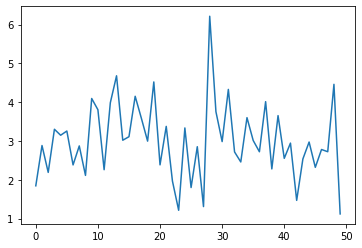

In [ ]:
b = random.normal(3, 1, 50)
plot(b)

In [ ]:
lr = []
for x in b:
  lr.append(pow(10, -x))
min(lr)

6.075148554049037e-07

In [ ]:
# set the parameter space boundary
rowIndex = best_configuration.index.values[0]
p_lr = {
     'lr': lr,
     'activation':[best_configuration.activation.get(rowIndex)],
     'optimizer': [optimizers.nadam],
     'losses': [best_configuration.losses.get(rowIndex)],
     'shapes': [best_configuration.shapes.get(rowIndex)],
     'first_neuron': [best_configuration.first_neuron.get(rowIndex)],
     'hidden_layers':[best_configuration.hidden_layers.get(rowIndex)],
     'dropout': [best_configuration.dropout.get(rowIndex)],
     'batch_size': [best_configuration.batch_size.get(rowIndex)],
     'epochs': [best_configuration.epochs.get(rowIndex)],
     'regularizer': [best_configuration.regularizer.get(rowIndex)]
     }

Running random search

In [ ]:
# start the experiment
scan_object_lr = talos.Scan(x=dsMISO1_trainX,
                         y=dsMISO1_trainY,
                         x_val=dsMISO1_valX,
                         y_val=dsMISO1_valY,
                         params=p_lr,
                         model=MISO1_model,
                         experiment_name='MISO1_lr',
                         fraction_limit = 10
                         )

  0%|          | 0/10 [00:00<?, ?it/s]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.0010346788825396523, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 10%|█         | 1/10 [00:13<01:57, 13.04s/it]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.0010071143270764186, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 20%|██        | 2/10 [00:26<01:44, 13.04s/it]

...

 80%|████████  | 8/10 [01:45<00:26, 13.32s/it]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 6.075148554049037e-07, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 90%|█████████ | 9/10 [01:58<00:13, 13.29s/it]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.0001030187908838644, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


100%|██████████| 10/10 [02:12<00:00, 13.27s/it]


In [ ]:
# Make a report on the scan
r = talos.Reporting(scan_object_lr)
best_configuration = r.data[r.data['val_mean_squared_error'] == r.low('val_mean_squared_error')]
best_configuration

,round_epochs,val_loss,val_mean_absolute_error,val_mean_squared_error,loss,mean_absolute_error,mean_squared_error,activation,batch_size,dropout,epochs,first_neuron,hidden_layers,losses,lr,optimizer,regularizer,shapes
6,200,0.000774,0.016203,0.000774,0.000822,0.017987,0.000822,relu,512,0.2,200,64,1,mean_squared_error,0.001338,<class 'keras.optimizers.Nadam'>,0.6,triangle


# MISO1: Prediction
Prediction using the best model obtained with hyperparameters scanning on MISO1.

In [ ]:
best_model = scan_object_lr.best_model(metric='val_mean_squared_error', asc=True)
predicted_q = best_model.predict(dsMISO1_testX)
best_model.save('MISO1/best_model_MISO1.h5')

# MISO2: Talos Grid Search

Adding the column for Inflow at previous day, as obtained in prediction of MISO1.

In [ ]:
IN_p1d_train = best_model.predict(dsMISO1_train.drop(columns='IN_p1d'))
IN_p1d_test = best_model.predict(dsMISO1_test.drop(columns='IN_p1d'))
dsMISO2_train.IN_p1d = IN_p1d_train
dsMISO2_test.IN_p1d = IN_p1d_test

dsMISO2_testY = dsMISO2_test.IN_p2d
dsMISO2_testX = dsMISO2_test.drop(columns='IN_p2d').values
dsMISO2_trainX, dsMISO2_trainY, dsMISO2_valX, dsMISO2_valY = wrangle.array_split(dsMISO2_train.drop(columns='IN_p2d').values, dsMISO2_train.IN_p2d, .3)

In [ ]:
# set the parameter space boundary
p = {
     'lr': [pow(10, -3)],
     'activation':['relu'],
     'optimizer': [optimizers.adam, optimizers.nadam],
     'losses': ['mean_squared_error'],
     'shapes': ['triangle'],
     'first_neuron': [64, 128],
     'hidden_layers':[1],
     'dropout': [.2],
     'batch_size': [128,256,512],
     'epochs': [100, 150, 200],
     'regularizer': [1, 0.6, 0.8]
     #'last_activation': [sigmoid]
     }

# define the input model
def MISO2_model(x_train, y_train, x_val, y_val, params):
    print("\nParams:",params)
    model = Sequential()
    model.add(Dense(params['first_neuron'], input_dim=12, activation=params['activation']))

    talos.utils.hidden_layers(model, params, 1)

    model.add(Dense(1, activation='relu'))
    opt = params['optimizer'](params['lr'], beta_1=0.9, beta_2=0.999)
    model.compile(optimizer=opt, loss=params['losses'], metrics=['mae','mse'])
    #(lr=talos.model.normalizers.lr_normalizer(params['lr']))

    # simple early stopping
    es = EarlyStopping(monitor='val_mae', mode='min', verbose=1)

    out = model.fit(x_train, y_train, callbacks=[es],
                    batch_size=params['batch_size'],
                    epochs=params['epochs'],
                    validation_data=[x_val, y_val],
                    #validation_split=0.3,
                    verbose=0)

    return out, model

In [ ]:
# start the experiment
scan_object2 = talos.Scan(x=dsMISO2_trainX,
                         y=dsMISO2_trainY,
                         x_val=dsMISO2_valX,
                         y_val=dsMISO2_valY,
                         params=p,
                         model=MISO2_model,
                         #grid_downsapmple=0.2,
                         experiment_name='MISO2',
                         round_limit=5
                         )

  0%|          | 0/5 [00:00<?, ?it/s]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 150, 'first_neuron': 128, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Adam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 20%|██        | 1/5 [00:14<00:59, 14.79s/it]


Params: {'activation': 'relu', 'batch_size': 128, 'dropout': 0.2, 'epochs': 150, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Adam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 40%|████      | 2/5 [00:38<00:52, 17.45s/it]

...

 60%|██████    | 3/5 [00:48<00:30, 15.18s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 128, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 1, 'shapes': 'triangle'}


 80%|████████  | 4/5 [01:13<00:18, 18.11s/it]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Adam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


100%|██████████| 5/5 [01:26<00:00, 16.55s/it]


In [ ]:
# Make a report on the scan
r2 = talos.Reporting(scan_object2)
# Show the models
display(r2.data)

,round_epochs,val_loss,val_mean_absolute_error,val_mean_squared_error,loss,mean_absolute_error,mean_squared_error,activation,batch_size,dropout,epochs,first_neuron,hidden_layers,losses,lr,optimizer,regularizer,shapes
0,150,0.000995,0.017756,0.000995,0.000640,0.016786,0.000640,relu,512,0.2,150,128,1,mean_squared_error,0.001,<class 'keras.optimizers.Adam'>,0.8,triangle
1,150,0.000954,0.017519,0.000954,0.000700,0.017418,0.000700,relu,128,0.2,150,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Adam'>,0.6,triangle
2,100,0.000938,0.017501,0.000938,0.000746,0.017552,0.000746,relu,256,0.2,100,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.8,triangle
3,200,0.001113,0.017790,0.001113,0.000614,0.016311,0.000614,relu,256,0.2,200,128,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,1.0,triangle
4,200,0.001033,0.017791,0.001033,0.000741,0.017753,0.000741,relu,512,0.2,200,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Adam'>,0.8,triangle


In [ ]:
best_configuration2 = r2.data[r2.data['val_mean_squared_error'] == r2.low('val_mean_squared_error')]

# MISO2: Talos Random Search for LR

Learning Rate is the most important hyperparameter in Deep Learning: for this reason, starting from the best configuration obtained with the Grid Search, now we specialize a random search for capturing the best Learning Rate value.

Gaussian distribution for exponent in learning rate

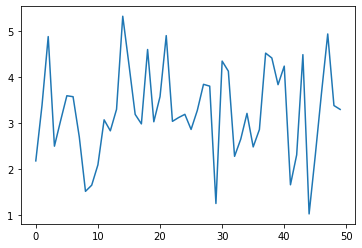

In [ ]:
b = random.normal(3, 1, 50)
plot(b)

In [ ]:
lr = []
for x in b:
  lr.append(pow(10, -x))
min(lr)

4.836565177659112e-06

In [ ]:
# set the parameter space boundary
rowIndex = best_configuration2.index.values[0]
p_lr = {
     'lr': lr,
     'activation':[best_configuration2.activation.get(rowIndex)],
     'optimizer': [optimizers.nadam],
     'losses': [best_configuration2.losses.get(rowIndex)],
     'shapes': [best_configuration2.shapes.get(rowIndex)],
     'first_neuron': [best_configuration2.first_neuron.get(rowIndex)],
     'hidden_layers':[best_configuration2.hidden_layers.get(rowIndex)],
     'dropout': [best_configuration2.dropout.get(rowIndex)],
     'batch_size': [best_configuration2.batch_size.get(rowIndex)],
     'epochs': [best_configuration2.epochs.get(rowIndex)],
     'regularizer': [best_configuration2.regularizer.get(rowIndex)]
     }

Running random search

In [ ]:
# start the experiment
scan_object2_lr = talos.Scan(x=dsMISO2_trainX,
                         y=dsMISO2_trainY,
                         x_val=dsMISO2_valX,
                         y_val=dsMISO2_valY,
                         params=p_lr,
                         model=MISO2_model,
                         experiment_name='MISO2_lr',
                         fraction_limit=10
                         )

  0%|          | 0/10 [00:00<?, ?it/s]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.0006533468224523151, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 10%|█         | 1/10 [00:10<01:30, 10.08s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.00014785241070765985, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 20%|██        | 2/10 [00:20<01:20, 10.08s/it]

...

 80%|████████  | 8/10 [01:20<00:19,  9.98s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 1.3367847077436348e-05, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 90%|█████████ | 9/10 [01:29<00:09,  9.95s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.0009447505270542696, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


100%|██████████| 10/10 [01:39<00:00,  9.94s/it]


In [ ]:
# Make a report on the scan
r = talos.Reporting(scan_object2_lr)
best_configuration2 = r.data[r.data['val_mean_squared_error'] == r.low('val_mean_squared_error')]
best_configuration2

,round_epochs,val_loss,val_mean_absolute_error,val_mean_squared_error,loss,mean_absolute_error,mean_squared_error,activation,batch_size,dropout,epochs,first_neuron,hidden_layers,losses,lr,optimizer,regularizer,shapes
0,100,0.000925,0.017419,0.000925,0.000816,0.018077,0.000816,relu,256,0.2,100,64,1,mean_squared_error,0.000653,<class 'keras.optimizers.Nadam'>,0.8,triangle


# MISO2: Prediction

In [ ]:
best_model2 = scan_object2_lr.best_model(metric='val_mean_squared_error', asc=True)
predicted_q2 = best_model2.predict(dsMISO2_testX)
best_model2.save('MISO2/best_model_MISO2.h5')

# MISO3: Talos Grid Search


Adding the columns for Inflow at previous day, as obtained in prediction of MISO1 and MISO2.

In [ ]:
IN_p2d_train = best_model2.predict(dsMISO2_train.drop(columns='IN_p2d'))
IN_p2d_test = best_model2.predict(dsMISO2_test.drop(columns='IN_p2d'))

dsMISO3_train.IN_p1d = IN_p1d_train
dsMISO3_test.IN_p1d = IN_p1d_test
dsMISO3_train.IN_p2d = IN_p2d_train
dsMISO3_test.IN_p2d = IN_p2d_test

dsMISO3_testY = dsMISO3_test.IN_p3d
dsMISO3_testX = dsMISO3_test.drop(columns='IN_p3d').values
dsMISO3_trainX, dsMISO3_trainY, dsMISO3_valX, dsMISO3_valY = wrangle.array_split(dsMISO3_train.drop(columns='IN_p3d').values, dsMISO3_train.IN_p3d, .3)

In [ ]:
# set the parameter space boundary
p = {
     'lr': [pow(10, -3)],
     'activation':['relu'],
     'optimizer': [optimizers.adam, optimizers.nadam],
     'losses': ['mean_squared_error'],
     'shapes': ['triangle'],
     'first_neuron': [64, 128],
     'hidden_layers':[1],
     'dropout': [.2],
     'batch_size': [128,256,512],
     'epochs': [100, 150, 200],
     'regularizer': [1, 0.6, 0.8]
     #'last_activation': [sigmoid]
     }

# define the input model
def MISO3_model(x_train, y_train, x_val, y_val, params):
    print("\nParams:",params)
    model = Sequential()
    model.add(Dense(params['first_neuron'], input_dim=10, activation=params['activation']))

    talos.utils.hidden_layers(model, params, 1)

    model.add(Dense(1, activation='relu'))
    opt = params['optimizer'](params['lr'], beta_1=0.9, beta_2=0.999)
    model.compile(optimizer=opt, loss=params['losses'], metrics=['mae','mse'])
    #(lr=talos.model.normalizers.lr_normalizer(params['lr']))

    # simple early stopping
    es = EarlyStopping(monitor='val_mae', mode='min', verbose=1)

    out = model.fit(x_train, y_train, callbacks=[es],
                    batch_size=params['batch_size'],
                    epochs=params['epochs'],
                    validation_data=[x_val, y_val],
                    #validation_split=0.3,
                    verbose=0)

    return out, model

In [ ]:
# start the experiment
scan_object3 = talos.Scan(x=dsMISO3_trainX,
                         y=dsMISO3_trainY,
                         x_val=dsMISO3_valX,
                         y_val=dsMISO3_valY,
                         params=p,
                         model=MISO3_model,
                         #grid_downsapmple=0.2,
                         experiment_name='MISO3',
                         round_limit=5
                         )

  0%|          | 0/5 [00:00<?, ?it/s]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 150, 'first_neuron': 128, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Adam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 20%|██        | 1/5 [00:19<01:17, 19.31s/it]


Params: {'activation': 'relu', 'batch_size': 512, 'dropout': 0.2, 'epochs': 150, 'first_neuron': 128, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Adam'>, 'regularizer': 0.8, 'shapes': 'triangle'}


 40%|████      | 2/5 [00:34<00:53, 17.97s/it]

...

 60%|██████    | 3/5 [00:41<00:29, 14.68s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Adam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 80%|████████  | 4/5 [00:51<00:13, 13.24s/it]


Params: {'activation': 'relu', 'batch_size': 128, 'dropout': 0.2, 'epochs': 200, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.001, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


100%|██████████| 5/5 [01:23<00:00, 18.87s/it]


In [ ]:
# Make a report on the scan
r3 = talos.Reporting(scan_object3)
# Show the models
display(r3.data)

,round_epochs,val_loss,val_mean_absolute_error,val_mean_squared_error,loss,mean_absolute_error,mean_squared_error,activation,batch_size,dropout,epochs,first_neuron,hidden_layers,losses,lr,optimizer,regularizer,shapes
0,150,0.000822,0.017615,0.000822,0.000702,0.017464,0.000702,relu,256,0.2,150,128,1,mean_squared_error,0.001,<class 'keras.optimizers.Adam'>,0.8,triangle
1,150,0.000801,0.017594,0.000801,0.000687,0.017369,0.000687,relu,512,0.2,150,128,1,mean_squared_error,0.001,<class 'keras.optimizers.Adam'>,0.8,triangle
2,100,0.000793,0.018294,0.000793,0.000813,0.018213,0.000813,relu,512,0.2,100,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,1.0,triangle
3,100,0.000758,0.017281,0.000758,0.000815,0.018413,0.000815,relu,256,0.2,100,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Adam'>,0.6,triangle
4,200,0.000817,0.017257,0.000817,0.000731,0.017751,0.000731,relu,128,0.2,200,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Nadam'>,0.6,triangle


In [ ]:
best_configuration3 = r3.data[r3.data['val_mean_squared_error'] == r3.low('val_mean_squared_error')]

# MISO3: Talos Random Search for LR

Learning Rate is the most important hyperparameter in Deep Learning: for this reason, starting from the best configuration obtained with the Grid Search, now we specialize a random search for capturing the best Learning Rate value.

Gaussian distribution for exponent in learning rate

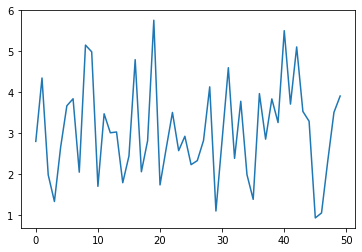

In [ ]:
b = random.normal(3, 1, 50)
plot(b)

In [ ]:
lr = []
for x in b:
  lr.append(pow(10, -x))
min(lr)

1.732709933779445e-06

In [ ]:
# set the parameter space boundary
rowIndex = best_configuration3.index.values[0]
p_lr = {
     'lr': lr,
     'activation':[best_configuration3.activation.get(rowIndex)],
     'optimizer': [optimizers.nadam],
     'losses': [best_configuration3.losses.get(rowIndex)],
     'shapes': [best_configuration3.shapes.get(rowIndex)],
     'first_neuron': [best_configuration3.first_neuron.get(rowIndex)],
     'hidden_layers':[best_configuration3.hidden_layers.get(rowIndex)],
     'dropout': [best_configuration3.dropout.get(rowIndex)],
     'batch_size': [best_configuration3.batch_size.get(rowIndex)],
     'epochs': [best_configuration3.epochs.get(rowIndex)],
     'regularizer': [best_configuration3.regularizer.get(rowIndex)]
     }

Running random search

In [ ]:
# start the experiment
scan_object3_lr = talos.Scan(x=dsMISO3_trainX,
                         y=dsMISO3_trainY,
                         x_val=dsMISO3_valX,
                         y_val=dsMISO3_valY,
                         params=p_lr,
                         model=MISO3_model,
                         #grid_downsapmple=0.2,
                         experiment_name='MISO3_lr',
                         fraction_limit = 10
                         )

  0%|          | 0/10 [00:00<?, ?it/s]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.01825149934640688, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 10%|█         | 1/10 [00:09<01:29,  9.99s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.008700157673696033, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 20%|██        | 2/10 [00:19<01:19,  9.95s/it]

...

 80%|████████  | 8/10 [01:20<00:20, 10.02s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 7.341240898857159e-05, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


 90%|█████████ | 9/10 [01:30<00:10, 10.03s/it]


Params: {'activation': 'relu', 'batch_size': 256, 'dropout': 0.2, 'epochs': 100, 'first_neuron': 64, 'hidden_layers': 1, 'losses': 'mean_squared_error', 'lr': 0.0014306528968057056, 'optimizer': <class 'keras.optimizers.Nadam'>, 'regularizer': 0.6, 'shapes': 'triangle'}


100%|██████████| 10/10 [01:39<00:00,  9.98s/it]


In [ ]:
# Make a report on the scan
r = talos.Reporting(scan_object3)
best_configuration3 = r.data[r.data['val_mean_squared_error'] == r.low('val_mean_squared_error')]
best_configuration3

,round_epochs,val_loss,val_mean_absolute_error,val_mean_squared_error,loss,mean_absolute_error,mean_squared_error,activation,batch_size,dropout,epochs,first_neuron,hidden_layers,losses,lr,optimizer,regularizer,shapes
3,100,0.000758,0.017281,0.000758,0.000815,0.018413,0.000815,relu,256,0.2,100,64,1,mean_squared_error,0.001,<class 'keras.optimizers.Adam'>,0.6,triangle


# MISO3: Prediction

In [ ]:
best_model3 = scan_object3_lr.best_model(metric='val_mean_squared_error', asc=True)
predicted_q3 = best_model3.predict(dsMISO3_testX)
best_model3.save('MISO3/best_model_MISO3.h5')

# Results Validation
Results validation for MISO1

In [ ]:
MAE_MISO1 = mean_absolute_error(denorm0(dsMISO1_testY), denorm0(predicted_q))

In [ ]:
MSE_MISO1 = sqrt(mean_squared_error(denorm0(dsMISO1_testY), denorm0(predicted_q)))

In [ ]:
dsMISO1_testY = np.array(dsMISO1_testY)
predicted_q = np.array(predicted_q)
predicted_q = predicted_q[:,0]
NSE_MISO1 = nse(denorm0(dsMISO1_testY), denorm0(predicted_q))

Reulsts validation for MISO2

In [ ]:
MAE_MISO2 = mean_absolute_error(denorm0(dsMISO2_testY), denorm0(predicted_q2))

MSE_MISO2 = sqrt(mean_squared_error(denorm0(dsMISO2_testY), denorm0(predicted_q2)))

dsMISO2_testY = np.array(dsMISO2_testY)
predicted_q2 = np.array(predicted_q2)
predicted_q2 = predicted_q2[:,0]
NSE_MISO2 = nse(denorm0(dsMISO2_testY), denorm0(predicted_q2))

Results validation for MISO3

In [ ]:
MAE_MISO3 = mean_absolute_error(denorm0(dsMISO3_testY), denorm0(predicted_q3))

MSE_MISO3 = sqrt(mean_squared_error(denorm0(dsMISO3_testY), denorm0(predicted_q3)))

dsMISO3_testY = np.array(dsMISO3_testY)
predicted_q3 = np.array(predicted_q3)
predicted_q3 = predicted_q3[:,0]
NSE_MISO3 = nse(denorm0(dsMISO3_testY), denorm0(predicted_q3))

# Export results

In [ ]:
results = [['MISO1', MAE_MISO1, MSE_MISO1, NSE_MISO1], ['MISO2', MAE_MISO2, MSE_MISO2, NSE_MISO2],
           ['MISO3', MAE_MISO3, MSE_MISO3, NSE_MISO3]]
df_results = pd.DataFrame(results, columns=['Network', 'MAE', 'MSE', 'NSE'])
df_results.to_csv('output.csv',index = False)